(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

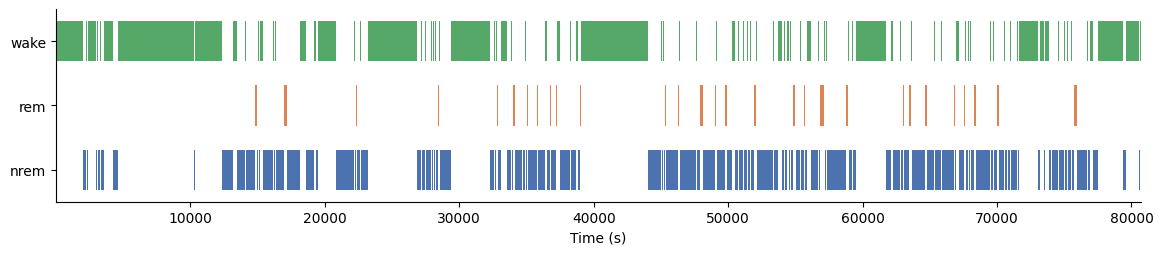

In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import plot_intervals

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

unit_id = '107b'
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes.npz")
turn_spikes     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "turn_spikes.npz")

plot_intervals(sleep_states, column='state')

In [223]:
ccg_nrem = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'nrem']),
    binsize=20,
    windowsize=800,
    time_units='ms',
    norm=False,
)

ccg_wake = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'wake']),
    binsize=200,
    windowsize=8001,
    time_units='ms',
    norm=False,
)

ccg_rem = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'rem']),
    binsize=200,
    windowsize=8001,
    time_units='ms',
    norm=False,
)

print(ccg_nrem.shape)
print(ccg_wake.shape)
print(ccg_rem.shape)

(81, 136)
(81, 136)
(81, 136)


In [225]:
order = np.argsort(ccg_wake.to_numpy().max(axis=0))
order

array([129,  90,  70,  80,  45,  47, 132,  34, 114, 134,   5,  30, 135,
        78,  69, 107,  57,  32,  72,  65, 125, 127,  40,  55,  11, 118,
        44, 110, 120,  33,  49,  99,   4,   3, 121,  95,  97,  20,  59,
       130,  19, 116,  26,  58, 112, 123,  79, 126,  53, 103,  81,   0,
        46,  15,  31,  91,  76, 105,  86,  42,  82,  17,  84,  22,   2,
        21,  74,  61,  75,  18,  24,  63,  28,  73,  60,  13,  50, 128,
        51,  56,   7,  71, 131, 111,  36,  27,  77,  92,  67, 122,  41,
        96,  48, 117,  93,   9,  66,  35, 104,  54,  12,  52, 113, 101,
         6, 119,  68,  98,  29, 108, 106,  38,  43, 133,  94,  83,  23,
        85,  87,  62,  64,  89,   8,  14, 124, 100,  25,  88,  16, 115,
       102,   1,  37, 109,  39,  10])

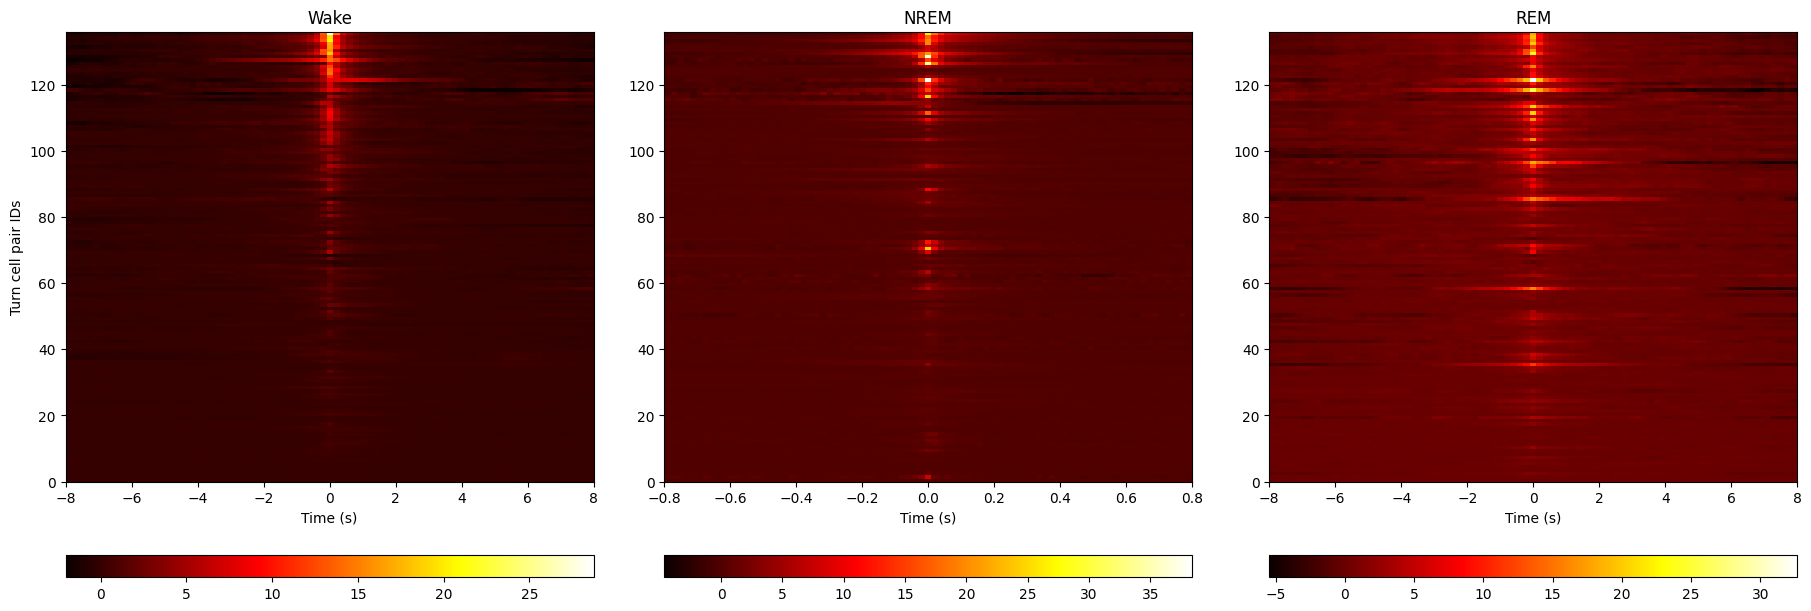

In [226]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(18, 6), constrained_layout=True, gridspec_kw={'height_ratios': [1, 0.05], 'wspace': 0.05, 'hspace': 0.1})

for i, ccg in enumerate([ccg_wake, ccg_nrem, ccg_rem]):
    data = ccg.to_numpy()
    data = data - np.median(data, axis=0)
    im = ax[0, i].imshow(
        data[:, order].T,
        aspect='auto',
        origin='lower',
        cmap='hot',
        interpolation='none',
        extent=[ccg.index.values[0], ccg.index.values[-1], 0, data.shape[1]]
        )
    ax[0, i].set_xlabel('Time (s)')
    cb = fig.colorbar(im, cax=ax[1, i], orientation='horizontal')

ax[0, 0].set_title('Wake')
ax[0, 1].set_title('NREM')
ax[0, 2].set_title('REM')

ax[0, 0].set_ylabel('Turn cell pair IDs')
plt.show()

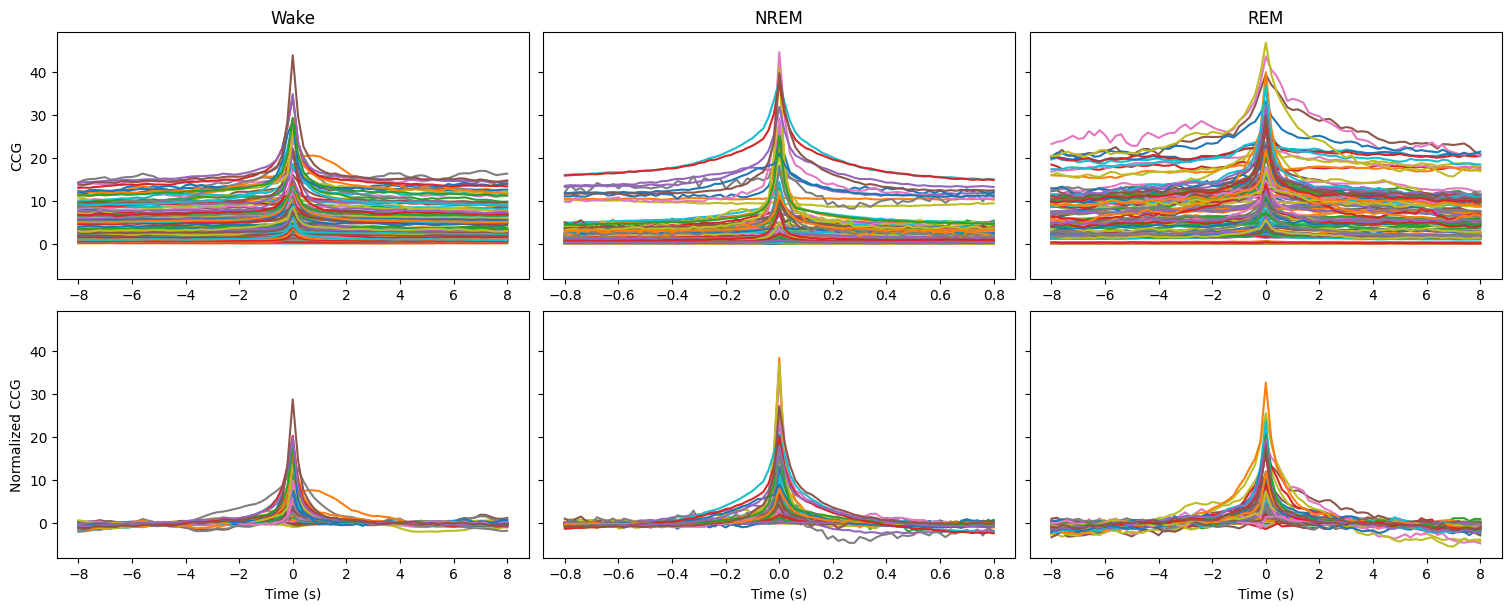

In [227]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharey=True, constrained_layout=True)

for i, ccg in enumerate([ccg_wake, ccg_nrem, ccg_rem]):
    data = ccg.to_numpy()
    ax[0, i].plot(ccg.index.values, data[:, order])
    data = data - np.median(data, axis=0)
    ax[1, i].plot(ccg.index.values, data[:, order])
    ax[1, i].set_xlabel('Time (s)')

ax[0, 0].set_title('Wake')
ax[0, 1].set_title('NREM')
ax[0, 2].set_title('REM')
ax[0, 0].set_ylabel('CCG')
ax[1, 0].set_ylabel('Normalized CCG')
plt.show()